In [1]:
#%load_ext autoreload 
#%autoreload 2

from networks.BP_network import *
from networks.DFC_network import *
from src.dataloaders import *
from src.trainers import Trainer, TrainerDFCL, TrainerDFCGen, TrainerCL, TrainerCL_DFC
from src.utils import *
from src.utils import *

/cluster/raid/home/sschwartz/.conda/envs/DFC_project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
config = {
        "layers": [784, 200, 10],
        "num_classes": 10,
        "lr": 1e-4, 
        "lr_fb": 1e-4, 
        "batch_size": 100,
        "batch_size_gen": 30000,
        "epochs": 10,
        "mode": "di",
        "num_workers": 0,
        "loss_fn": "ce",
        "optimizer": "Adam",
        "scheduler": "CosineAnnealingLR",
        "activation_fun": "Tanh",
        "device": "cuda",
        "output_dir": "./outputs",
        "seed": 1337,
        "taus": [0.02, 0.02, 0.02, 0.016, 0.01],
        "target_lr": 1,#1e-2,       # Updated to optimal value
        "alpha_di": 0.0017,        # 1/tau for tau=0.2
        "dt_di": 0.02,         # Time step
        "time_constant_ratio": 0.2,  # tau
        "tmax_di":100,
        "k_p": 2.0,             # Optimal for G=1, tau=0.2
        "eps": 1e-4,
        "save": True,
        "flatten_imgs": "default",
        "num_tasks": 2,
        "classes_per_task": 5,
        "setting": "classIL2task",
        "first_task_only": False,
}

config = dotdict(config)

In [3]:
tasks_dataloaders = ClassILMNIST2Task(config=config).get_all_tasks_dataloaders()

In [4]:
# Train model
model = DFCL_network(config=config)

trainer = TrainerCL_DFC(model, tasks_dataloaders, config)
trainer.train()

[DFCL] Feedback connections initialized.
Training:
 - layers: [784, 200, 10]
 - num_classes: 10
 - lr: 0.0001
 - lr_fb: 0.0001
 - batch_size: 100
 - batch_size_gen: 30000
 - epochs: 10
 - mode: di
 - num_workers: 0
 - loss_fn: ce
 - optimizer: Adam
 - scheduler: CosineAnnealingLR
 - activation_fun: Tanh
 - device: cuda
 - output_dir: ./outputs
 - seed: 1337
 - taus: [0.02, 0.02, 0.02, 0.016, 0.01]
 - target_lr: 1
 - alpha_di: 0.0017
 - dt_di: 0.02
 - time_constant_ratio: 0.2
 - tmax_di: 2
 - k_p: 2.0
 - eps: 0.0001
 - save: True
 - flatten_imgs: default
 - num_tasks: 2
 - classes_per_task: 5
 - setting: classIL2task
 - first_task_only: False
 - in_channels: 1
 - model: DFCL_network

[TrainerDFCL] Created optimizers: feedforward, 1× feedback.
Starting Task 1/2


Training epoch 001/10:   0%|          | 0/306 [00:00<?, ?batch/s]

				Epoch: 001, Train loss: 1.3064 & test losses: T0: 0.3907 & accuracy: T0: 92.51, Full: 92.49


				Epoch: 002, Train loss: 0.2841 & test losses: T0: 0.1618 & accuracy: T0: 96.32, Full: 96.32


				Epoch: 003, Train loss: 0.1604 & test losses: T0: 0.1137 & accuracy: T0: 97.30, Full: 97.30


...

				Epoch: 057, Train loss: 0.0126 & test losses: T0: 0.3520, T1: 0.0649 & accuracy: T0: 93.50, T1: 97.96, Full: 73.52


				Epoch: 058, Train loss: 0.0118 & test losses: T0: 0.3574, T1: 0.0619 & accuracy: T0: 93.19, T1: 98.05, Full: 72.13


				Epoch: 059, Train loss: 0.0113 & test losses: T0: 0.3654, T1: 0.0614 & accuracy: T0: 92.99, T1: 98.05, Full: 72.79


Training epoch 060/100:   0%|          | 0/295 [00:00<?, ?batch/s]

KeyboardInterrupt: 

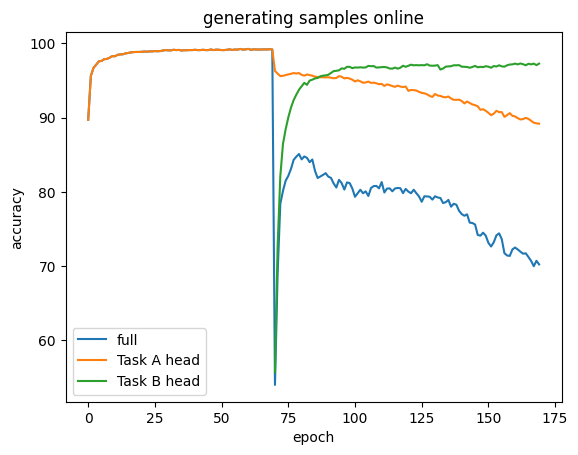

In [6]:
plt.plot(trainer.accuracies_full, label="full")
plt.plot(trainer.accuracies_tasks[0], label="Task A head")
plt.plot(range(70,170),trainer.accuracies_tasks[1], label="Task B head")
plt.title("generating samples online")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend()
plt.show()



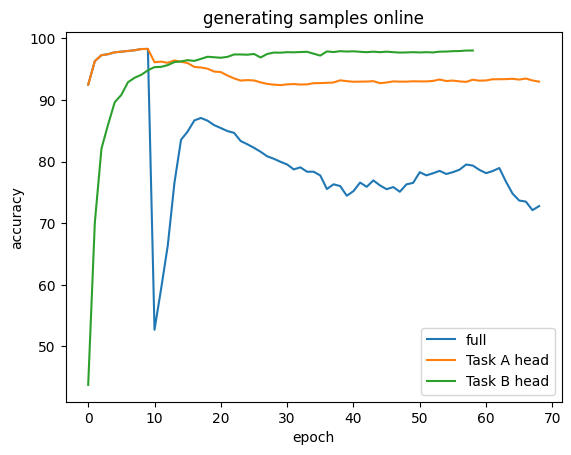

In [6]:
plt.plot(trainer.accuracies_full, label="full")
plt.plot(trainer.accuracies_tasks[0], label="Task A head")
plt.plot(trainer.accuracies_tasks[1], label="Task B head")
plt.title("generating samples online")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend()
plt.show()



In [ ]:
# Train model
model = BP_network(config=config)

trainer = TrainerCL(model, tasks_dataloaders, config)
trainer.train()

In [ ]:
for i in range(90,100):
    plot_generated_inputs(trainer.gen_samples[i][:50], n_cols=10, title="DFC Generated Inputs", save=False, filename="Samples_BP_100_epochs.png")

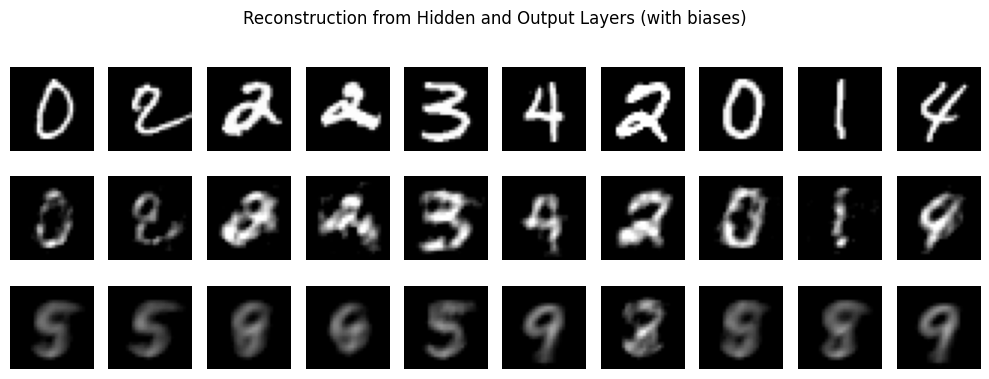

In [6]:
x1, x2, x3 = visualize_reconstructions(model, tasks_dataloaders[0][0], sm=True)

In [7]:
print(x2[5].max())

tensor(2.3736, device='cuda:0')


In [ ]:
plot_receptive_fields(model, n_cols=15)

In [5]:
(train_loss, train_acc), (test_loss, test_acc) = evaluate(model, tasks_dataloaders[0][0], tasks_dataloaders[0][1], device=model.device)

Train loss: 0.0140 | Train acc: 99.77%
Test  loss: 0.0304 | Test  acc: 99.01%


In [6]:
@torch.no_grad()
def _dynamical_inversion(model):
    # Setup
    layer_out_dims = [layer.weights.shape[0] for layer in model.layers]

    v_fb_current = [torch.zeros((model.bzs, lod)) for lod in layer_out_dims]
    v_ff_current = [torch.zeros((model.bzs, lod)) for lod in layer_out_dims]
    v_current = [torch.zeros((model.bzs, lod)) for lod in layer_out_dims]
    r_current = [torch.zeros((model.bzs, lod)) for lod in layer_out_dims]
    u_current = torch.zeros((model.bzs, model.output_size))
    u_int_current = torch.zeros((model.bzs, model.output_size))

    for i, layer in enumerate(model.layers):
        v_ff_current[i] = layer.v_ff
        v_current[i] = layer.v_ff
        r_current[i] = layer.r

    converged_mask = torch.zeros((model.bzs,), dtype=torch.bool)

    # Simulate tmax timesteps
    for t_step in range(model.tmax - 1):
        # Stop if converged

        error = model._compute_error(r_current[-1], model.targets)
        
        # Proportional and integral (PI) control.
        u_int_next = u_int_current + model.dt * (error - model.alpha * u_current)
        u_next = u_int_next + model.k_p * error

        # Compute convergence check
        #converged_mask |= torch.norm(u_next - u_current, dim=1) < model.eps
        converged_mask |= (torch.abs(error)).mean(dim=1) < 0.1

        if converged_mask.float().mean().item() >= 0.95:
            model.converged_per_batch.append(t_step)
            print("Converged!")
            break

        _, Js = model._calculate_full_jacobian()
        
        # Iterate over layers with control signal
        for i, layer in enumerate(model.layers):
            r_prev = r_current[i - 1] if i != 0 else model.input

            # Soma with apical
            tau = model.dt / model.time_constant_ratio

            # Basal and apical
            v_ff_current[i] += (r_prev.mm(layer.weights.t()) + layer.bias.unsqueeze(0) - v_ff_current[i]) * (~converged_mask.unsqueeze(1))
            v_ff_current[i] = v_ff_current[i].clone().detach()
            
            if i != len(model.layers) - 1:
                v_fb_current[i] = (model.feedback_layers[-(i + 1)](u_next))#* 0.1 * layer.activation_derivative(v_current[i])
                v_current[i] += tau * (v_fb_current[i] + v_ff_current[i] - v_current[i]) * (~converged_mask.unsqueeze(1))
            else:
                v_fb_current[i] = torch.bmm(Js[i].transpose(1, 2),u_next.unsqueeze(2)).squeeze(2)
                v_current[i] += tau * (v_fb_current[i] + v_ff_current[i] - v_current[i]) * (~converged_mask.unsqueeze(1))
                #v_current[i] += tau * (v_ff_current[i] - v_current[i]) * (~converged_mask.unsqueeze(1))
            
            r_current[i] = layer.activation_fn(v_current[i])
            

            layer.v_ff = v_current[i]
            layer.r = r_current[i]

        u_int_current = u_int_next
        u_current = u_next

    if not converged_mask.float().mean().item() >= 0.95:
        model.converged_per_batch.append(model.tmax)

    # Steady-state values per layer
    rs = [model.input]

    for i, layer in enumerate(model.layers):
        layer.r = r_current[i]
        layer.r_ff = layer.activation_fn(v_ff_current[i])
        layer.r_prev = rs[i]
        rs.append(r_current[i])

    #model.layers[-1].r_ff = model.layers[-1].r.clone().detach()
    #model.layers[-1].r = model.targets.clone().detach()
    return rs


In [ ]:
for batch in tasks_dataloaders[0][0]:
    model.tmax= 1000
    plot_generated_inputs(batch[0][:50], n_cols=10, title="DFC Generated Inputs", save=False, filename="Samples_BP_100_epochs.png")
    ypred = model(batch[0].to(model.device)).clone().detach()
    X = torch.clamp(model.feedback_layers[0](model.layers[0].r).clone().detach(), -0.4242, 2.8215)
    plot_generated_inputs(X[:50], n_cols=10, title="DFC Generated Inputs", save=False, filename="Samples_BP_100_epochs.png")
    model.targets = batch[1].to(model.device)
    rs = _dynamical_inversion(model)
    X = torch.clamp(model.feedback_layers[0](model.layers[0].r), -0.4242, 2.8215)
    plot_generated_inputs(X[:50], n_cols=10, title="DFC Generated Inputs", save=False, filename="Samples_BP_100_epochs.png")
    print(ypred.softmax(dim=1)[0].round(decimals=2))
    print(model.layers[-1].r.softmax(dim=1)[0].round(decimals=2))
    print(model.layers[-1].r_ff.softmax(dim=1)[0].round(decimals=2))
    break

In [ ]:
X_pred = torch.clamp(model.feedback_layers[-2](model.feedback_layers[-1](model.targets)), -0.4242, 2.8215)
X_pred2 = torch.clamp((model.layers[0].activation_fn(model.targets@model.layers[-1].weights))@model.layers[-2].weights, -0.4242, 2.8215)

plot_generated_inputs(X_pred[:50], n_cols=10, title="DFC Generated Inputs", save=False, filename="Samples_BP_100_epochs.png")
plot_generated_inputs(X_pred2[:50], n_cols=10, title="DFC Generated Inputs", save=False, filename="Samples_BP_100_epochs.png")



In [ ]:
for batch in tasks_dataloaders[1][0]:
    model.tmax= 10000
    plot_generated_inputs(batch[0][:50], n_cols=10, title="DFC Generated Inputs", save=False, filename="Samples_BP_100_epochs.png")
    ypred = model(batch[0].to(model.device))
    X = torch.clamp(model.feedback_layers[0](model.layers[0].r), -0.4242, 2.8215)
    plot_generated_inputs(X[:50], n_cols=10, title="DFC Generated Inputs", save=False, filename="Samples_BP_100_epochs.png")
    model.targets = batch[1].to(model.device)
    rs = model._dynamical_inversion()
    X = torch.clamp(model.feedback_layers[0](model.layers[0].r), -0.4242, 2.8215)
    plot_generated_inputs(X[:50], n_cols=10, title="DFC Generated Inputs", save=False, filename="Samples_BP_100_epochs.png")
    print(ypred[0])
    print(model.layers[-1].r[0])
    break

In [5]:
@torch.no_grad()
def generate_samples(model, target_activity, init_input=None, tmax=500, threshold=0.01):
    # === Setup ===
    model.bzs = target_activity.shape[0]

    input_pre = init_input.clone().detach()
    model.input = init_input.clone().detach()

    layer_out_dims = [layer.weights.shape[0] for layer in model.layers]

    v_fb_current = [torch.zeros((model.bzs, lod), device=model.device) for lod in layer_out_dims]
    v_ff_current = [torch.zeros((model.bzs, lod), device=model.device) for lod in layer_out_dims]
    v_current = [torch.zeros((model.bzs, lod), device=model.device) for lod in layer_out_dims]
    r_current = [torch.zeros((model.bzs, lod), device=model.device) for lod in layer_out_dims]
    u_current = torch.zeros((model.bzs, model.layer_sizes[-1]), device=model.device)
    u_int_current = torch.zeros_like(u_current)

    u_current2 = torch.zeros((model.bzs, model.layer_sizes[-2]), device=model.device)
    u_int_current2 = torch.zeros_like(u_current2)
    u_next2 = torch.zeros_like(u_current2)


    u_current3 = torch.zeros((model.bzs, model.input.shape[1]), device=model.device)
    u_int_current3 = torch.zeros_like(u_current3)
    u_next3 = torch.zeros_like(u_current3)

    # Forward init
    with torch.no_grad():
        r_prev = model.input
        for i, layer in enumerate(model.layers):
            v_ff_current[i] = r_prev.mm(layer.weights.t()) + layer.bias.unsqueeze(0)
            v_current[i] = v_ff_current[i]
            r_current[i] = layer.activation_fn(v_ff_current[i])
            r_prev = r_current[i]
    _ = model(model.input)


    converged_mask = torch.zeros((model.bzs,), dtype=torch.bool, device=model.device)

    diffs = []
    diffs2 = []
    video = [model.input[0].clone()]

    # === Dynamics ===
    for t in range(tmax - 1):
        """if converged_mask.all():
            break"""

        error = model._compute_error(r_current[-1], target_activity)

        # PI control
        u_int_next = u_int_current + model.dt * (error - model.alpha * u_current)
        u_next = u_int_next + model.k_p * error

        converged_mask = (torch.abs(error)).mean(dim=1) < threshold ### careful here

        _, Js = model._calculate_full_jacobian()

        for i, layer in enumerate(model.layers):
            r_prev = r_current[i - 1] if i != 0 else model.input

            # Basal + apical feedback
            v_ff_current[i] += (r_prev.mm(layer.weights.t()) + layer.bias.unsqueeze(0) - v_ff_current[i]) 
            v_ff_current[i] = v_ff_current[i].clone().detach()
            

            tau = model.dt / model.time_constant_ratio

            if i!=1:
                v_fb_current[i] = (model.feedback_layers[i+1](u_next)) * layer.activation_derivative(v_current[i])
                #v_fb_current[i] = u_next@model.layers[-1].weights * layer.activation_derivative(v_current[i])
                #v_current[i] += tau * (v_fb_current[i]* ~converged_mask.unsqueeze(1) + v_ff_current[i] - v_current[i] - u_next2) 
                v_current[i] += tau * (v_fb_current[i]* ~converged_mask.unsqueeze(1) + v_ff_current[i] - v_current[i]) 

            else:
                #v_current[i] +=  tau * (v_ff_current[i] - v_current[i])
                v_fb_current[i] = torch.bmm(Js[i].transpose(1, 2),u_next.unsqueeze(2)).squeeze(2)
                v_current[i] += tau * (v_fb_current[i] + v_ff_current[i] - v_current[i]) * (~converged_mask.unsqueeze(1))

            r_current[i] = layer.activation_fn(v_current[i])

            layer.v_ff = v_current[i]
            layer.r = r_current[i]

        u_int_current = u_int_next
        u_current = u_next

        error2 = model._compute_error_mse(model.layers[0].activation_fn(v_ff_current[0]), r_current[-2])
        # PI control
        u_int_next2 = u_int_current2 + model.dt * (error2 - model.alpha * u_current2)
        u_next2 = u_int_next2 + model.k_p * error2

        u_int_current2 = u_int_next2
        u_current2 = u_next2

        error3 = model._compute_error_mse(torch.clamp(model.feedback_layers[0](model.layers[0](model.input)),-0.4242 ,2.8215), model.input) 
        #error3 *= error3>0.3
        # PI control
        u_int_next3 = u_int_current3 + model.dt * (error3 - model.alpha * u_current3)
        u_next3 = u_int_next3 + model.k_p * error3

        
        grad_input = torch.clamp((model.feedback_layers[0](r_current[-2])), -0.4242 ,2.8215)
        grad_input += (model.feedback_layers[0](u_next2))#* converged_mask.unsqueeze(1)
        #grad_input -= u_next3
        #grad_input = torch.clamp(grad_input, -0.4242 ,2.8215)
        #grad_input = (model.feedback_layers[0](r_current[-2]))
        #input_pre += (grad_input + init_input_scaled - input_pre) * ~converged_mask.unsqueeze(1)
        #input_pre += tau * (grad_input)
        input_pre += tau* (grad_input-model.input)
        model.input = torch.clamp(input_pre, -0.4242 ,2.8215)
        video.append(model.input[0].clone())

        u_int_current3 = u_int_next3
        u_current3 = u_next3


        diff = torch.abs(r_current[0] - model.layers[0](model.input)).mean().detach().cpu().numpy()
        diff2 = torch.abs(model.input - torch.clamp(model.feedback_layers[0](model.layers[0](model.input)), -0.4242 ,2.8215)).mean().detach().cpu().numpy()
        diffs.append(diff)
        diffs2.append(diff2)
        
    # === Collect steady-state representations ===
    rs = [model.input]
    for i, layer in enumerate(model.layers):
        layer.r = r_current[i]
        layer.r_ff = layer.activation_fn(v_ff_current[i])
        layer.r_prev = rs[i]
        rs.append(r_current[i])

    generated_inputs = model.input#torch.clamp(model.feedback_layers[0](r_current[0]), -0.4242 ,2.8215).clone().detach()
    print(converged_mask.sum())
    print((target_activity.argmax(dim=1)==rs[-1].argmax(dim=1)).sum())

    return generated_inputs, torch.softmax(rs[-1],dim=1).clone().detach(), diffs, diffs2, video



In [20]:
batch_size = 30000
num_classes = 10

K = 6

#init_input = torch.clamp(torch.randn(batch_size, 200, device=model.device),-1,1)
init_input = 2 * torch.rand(batch_size, 200, device=model.device) - 1
init_input = torch.clamp(model.feedback_layers[0](init_input), -0.4242, 2.8215)

# sample random classes
rand = torch.randint(0, K - 1, (batch_size,), device=model.device)
target = F.one_hot(torch.tensor(rand), num_classes=10)
#target = torch.eye(10).repeat_interleave(int(batch_size/10), dim=0)

generated_input, rs_last, diffs, diffs2, video = generate_samples(model, target, init_input=init_input, tmax=1000, threshold=0.001)

tensor(29998, device='cuda:0')
tensor(30000, device='cuda:0')


In [23]:
batch_size = 100
num_classes = 10

Xs = []   
Ys = []
Y_preds = []

for batch in tasks_dataloaders[1][0]:
    ypred = model(batch[0].to(model.device))
    B, K = ypred.shape
    K = 6

    # argmax indices
    #top1 = batch[1].argmax(dim=1).to(model.device)  # (B,)
    # sample random classes
    #rand = torch.randint(0, K - 1, (B,), device=ypred.device) 
    # shift to skip argmax
    #rand = rand + (rand >= top1).long()

    #target = torch.eye(5).repeat_interleave(20, dim=0)
    #target = random_smooth_labels(targets=rand)
    #target = F.one_hot(torch.tensor(rand), num_classes=10).long()
    target = F.one_hot(torch.tensor(ypred.argmax(dim=1)), num_classes=10).long()
    Y_preds.append(target)
    
    Xs.append(batch[0])
    Ys.append(batch[1])   
    if batch_size==100:
        break

X = torch.cat(Xs, dim=0)
Y = torch.cat(Ys, dim=0)
Y_label = torch.argmax(Y,dim=1)
target = torch.cat(Y_preds,dim=0)

print("random targets generated ...")


generated_input, rs_last, diffs, diffs2, video = generate_samples(model, target, init_input=X.to(model.device), tmax=2000, threshold=0.1)


random targets generated ...
tensor(100, device='cuda:0')
tensor(100, device='cuda:0')


In [43]:
batch_size = 100
num_classes = 10

K = 6

#init_input = torch.clamp(torch.randn(batch_size, 200, device=model.device),-1,1)
init_input = 2 * torch.rand(batch_size, 200, device=model.device) - 1
init_input = torch.clamp(model.feedback_layers[0](init_input), -0.4242, 2.8215)

# sample random classes
rand = torch.randint(0, K - 1, (batch_size,), device=model.device)
target = F.one_hot(torch.tensor(rand), num_classes=10)
#target = torch.eye(10).repeat_interleave(int(batch_size/10), dim=0)

generated_input, rs_last, diffs = model.generate_samples(target, init_input=init_input, tmax=4000, threshold=0.0001)

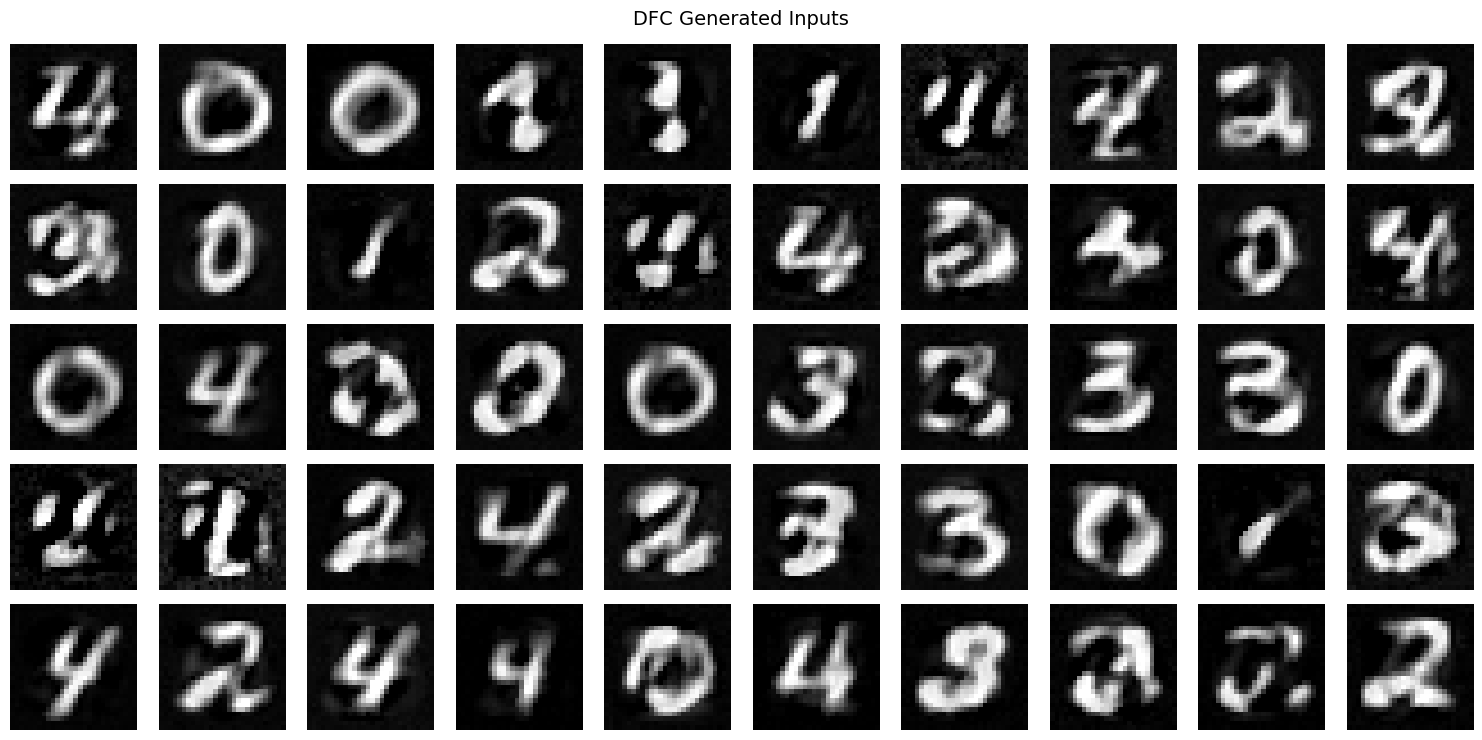

In [21]:
plot_generated_inputs(generated_input[:50], n_cols=10, title="DFC Generated Inputs", save=False, filename="Samples_BP_100_epochs.png")

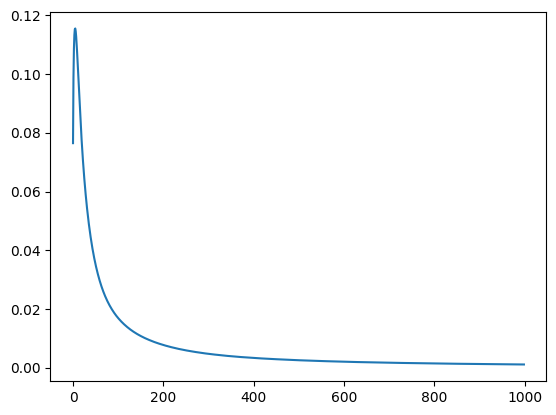

In [22]:
plt.plot(diffs)
plt.show()
#plt.plot(diffs2)
#plt.show()

In [23]:
print(target.argmax(dim=1))
print(model(generated_input).argmax(dim=1))
print((target.argmax(dim=1)==model(generated_input).argmax(dim=1)).sum())

tensor([4, 0, 0,  ..., 2, 4, 4], device='cuda:0')
tensor([4, 0, 0,  ..., 2, 4, 4], device='cuda:0')
tensor(27921, device='cuda:0')


In [357]:
torch.abs(x1 - x3).mean().detach().cpu().numpy()

array(0.34253195, dtype=float32)

In [ ]:
generated_input = in_mod

In [17]:
print(generated_input[0].max())

tensor(2.9052, device='cuda:0', grad_fn=<MaxBackward1>)


In [ ]:
print(generated_input.min())
print(model(generated_input).softmax(dim=1)[2])


tensor(-0.4242, device='cuda:0')
tensor([2.4205e-03, 5.4211e-06, 9.4153e-01, 8.6285e-03, 4.7348e-02, 7.7884e-06,
        1.4666e-05, 2.0089e-05, 5.3112e-06, 1.7526e-05], device='cuda:0',
       grad_fn=<SelectBackward0>)


In [ ]:
a, b = -0.4242, 2.8215

x = generated_input

x_scaled = torch.empty_like(x)

# negative part
neg_mask = x < 0
x_scaled[neg_mask] = x[neg_mask] / x[neg_mask].abs().max() * abs(a)

# positive part
pos_mask = x > 0
x_scaled[pos_mask] = x[pos_mask] / x[pos_mask].max() * b


In [72]:
in_mod = torch.clamp(model.feedback_layers[0](model.layers[0].r),-0.4242, 2.8215)

d = torch.abs(model.layers[0].r - model.layers[0](in_mod)).mean().detach().cpu().numpy()
print(d)
print(diffs[-1])

0.07051959
0.033095334


In [73]:
generated_input = in_mod

In [ ]:
from torch.distributions import Dirichlet

def random_smooth_labels(targets, num_classes=10, alpha_correct=50.0, alpha_other=0.1):
    """
    targets: (N,) integer labels
    """
    N = targets.size(0)
    alpha = torch.full((N, num_classes), alpha_other, device=targets.device)
    alpha.scatter_(1, targets.unsqueeze(1), alpha_correct)

    dist = Dirichlet(alpha)
    return dist.sample()

In [ ]:
batch_size = 30000
num_classes = 10

Xs = []   
Ys = []
Y_preds = []

for batch in tasks_dataloaders[1][0]:
    ypred = model(batch[0].to(model.device))
    B, K = ypred.shape
    K = 6

    # argmax indices
    top1 = batch[1].argmax(dim=1).to(model.device)  # (B,)
    # sample random classes
    rand = torch.randint(0, K - 1, (B,), device=ypred.device) 
    # shift to skip argmax
    rand = rand + (rand >= top1).long()

    #target = torch.eye(5).repeat_interleave(20, dim=0)
    #target = random_smooth_labels(targets=rand)
    target = F.one_hot(torch.tensor(rand), num_classes=10).long()
    Y_preds.append(target)
    
    Xs.append(batch[0])
    Ys.append(batch[1])   
    if batch_size==100:
        break

X = torch.cat(Xs, dim=0)
Y = torch.cat(Ys, dim=0)
Y_label = torch.argmax(Y,dim=1)
target = torch.cat(Y_preds,dim=0)

print("random targets generated ...")


generated_input2, rs_last = model.generate_samples(target, init_input=X.to(model.device), tmax=5000, threshold=0.001)


/cluster/raid/home/sschwartz/.conda/envs/DFC_project/lib/python3.11/site-packages/torch/utils/_device.py:109: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


random targets generated ...


In [ ]:
plot_generated_inputs(generated_input2[:100], n_cols=10, title="DFC Generated Inputs", save=False, filename="Samples_BP_100_epochs.png")

In [ ]:
for i in range(10):
    print(i)
    print(Y_label[10*i:(10*i+10)])
    print(target.argmax(dim=1)[10*i:(10*i+10)])

In [24]:
import joblib
from tqdm import tqdm


# --- 1. Load MNIST ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 -> 784
])
mnist_train = datasets.MNIST(root="./data", train=True, transform=transform, download=True)

# Convert entire dataset to tensors
X = torch.stack([mnist_train[i][0] for i in tqdm(range(len(mnist_train)), desc="Loading MNIST")])
y = torch.tensor([mnist_train[i][1] for i in range(len(mnist_train))])

# Load UMAP model
reducer = joblib.load("umap_model.pkl")

# Load embedding
embedding = np.load("mnist_umap_embedding.npy")

Loading MNIST: 100%|██████████| 60000/60000 [00:06<00:00, 9344.20it/s]


In [8]:
video = []
video_labels = []
for j in range(1):
    x_final = trainer.gen_samples[j].clone().detach().cpu()
    y_labels = trainer.gen_targets[j].clone().detach().cpu()

    embedding_gen = reducer.transform(x_final.numpy())
    print("Generated embedding shape:", embedding_gen.shape)
    video.append(embedding_gen)
    video_labels.append(y_labels)


Generated embedding shape: (30000, 2)


In [9]:
for i, v in enumerate(video_labels):
    v = v.argmax(dim=1)
    video_labels[i] = v

In [10]:
print(video_labels[0])

tensor([0, 3, 0,  ..., 4, 0, 3])


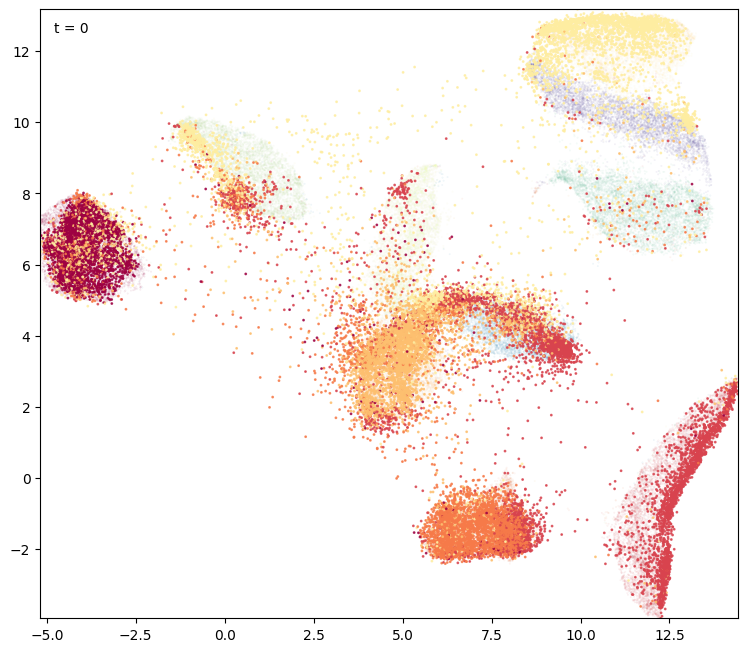

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

# Torch → numpy if needed
vid = video.detach().cpu().numpy() if hasattr(video, "detach") else np.asarray(video)
lab = video_labels.detach().cpu().numpy() if hasattr(video_labels, "detach") else np.asarray(video_labels)

T, N, _ = vid.shape

fig, ax = plt.subplots(figsize=(9, 9))

# Fixed axis limits for stability
xmin, ymin = vid.reshape(-1, 2).min(axis=0)
xmax, ymax = vid.reshape(-1, 2).max(axis=0)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")

# Plot MNIST samples
scatter_mnist = plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=y.cpu(), cmap="Spectral", s=0.1, alpha=0.1, label="MNIST",vmin=0, vmax=9
)

# Initial scatter
sc = ax.scatter(
    vid[0, :, 0],
    vid[0, :, 1],
    c=lab[0],
    cmap="Spectral", s=1, alpha=0.8,
    vmin=0,
    vmax=9,
)

time_text = ax.text(0.02, 0.98, "", transform=ax.transAxes, va="top")

def update(t):
    sc.set_offsets(vid[t])
    sc.set_array(lab[t])   # <-- update labels/colors
    time_text.set_text(f"t = {t}")
    return sc, time_text

ani = animation.FuncAnimation(
    fig,
    update,
    frames=T,
    interval=50,
    blit=True
)

plt.show()


In [11]:
ani.save('morphing_animations/umap_representation_drift_CL_2.gif', writer='pillow', fps=2)

Animation.save using <class 'matplotlib.animation.PillowWriter'>


In [ ]:
print((target.argmax(dim=1).detach().cpu()==y_labels).sum())
(target.argmax(dim=1).detach().cpu()==y_labels).sum()/y_labels.shape[0]

tensor(29737)


tensor(0.9912)

In [ ]:
generated_input = in_mod

Generated embedding shape: (30000, 2)


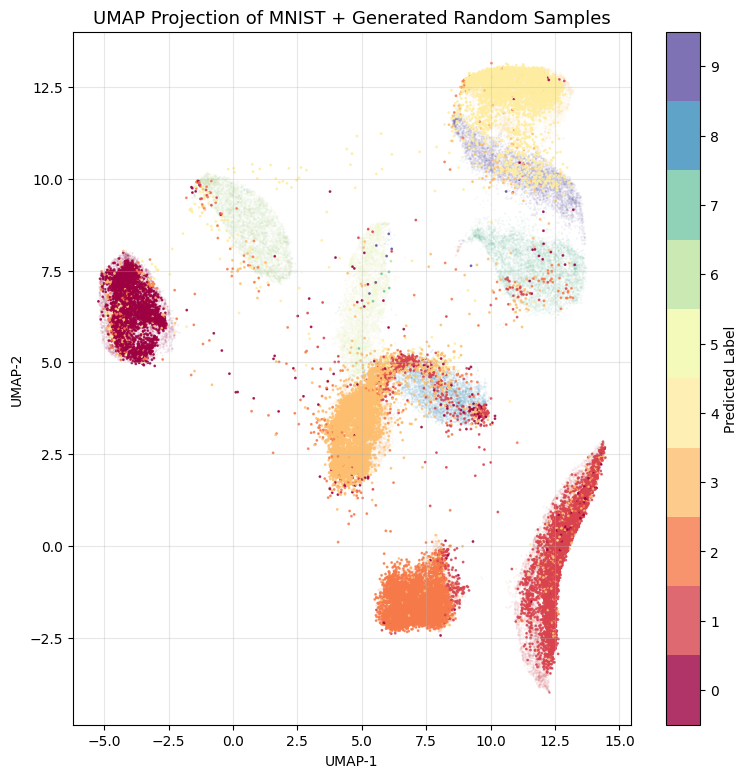

In [25]:
x_final = generated_input.clone().detach().cpu()
sm = torch.nn.Softmax(dim=1)
#y_hat = sm(rs_last)
y_hat = (sm(model(generated_input)).clone().detach()).cpu()
y_labels = torch.argmax(y_hat, dim=1)

embedding_gen = reducer.transform(x_final.numpy())
print("Generated embedding shape:", embedding_gen.shape)

# --- Plot ---
plt.figure(figsize=(9, 9))

# Plot MNIST samples
scatter_mnist = plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=y.cpu(), cmap="Spectral", s=0.1, alpha=0.1, label="MNIST",vmin=0, vmax=9
)

# Plot generated samples
scatter_gen = plt.scatter(
    embedding_gen[:, 0], embedding_gen[:, 1],
    c=y_labels.cpu(), cmap="Spectral", s=1, alpha=0.8, label="Generated",vmin=0, vmax=9
)

plt.title("UMAP Projection of MNIST + Generated Random Samples", fontsize=13)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True, alpha=0.3)

# Choose which scatter to colorbar — here, the generated one
cbar = plt.colorbar(scatter_gen, boundaries=np.arange(11)-0.5, ticks=np.arange(10))
cbar.set_label("Predicted Label")

plt.show()


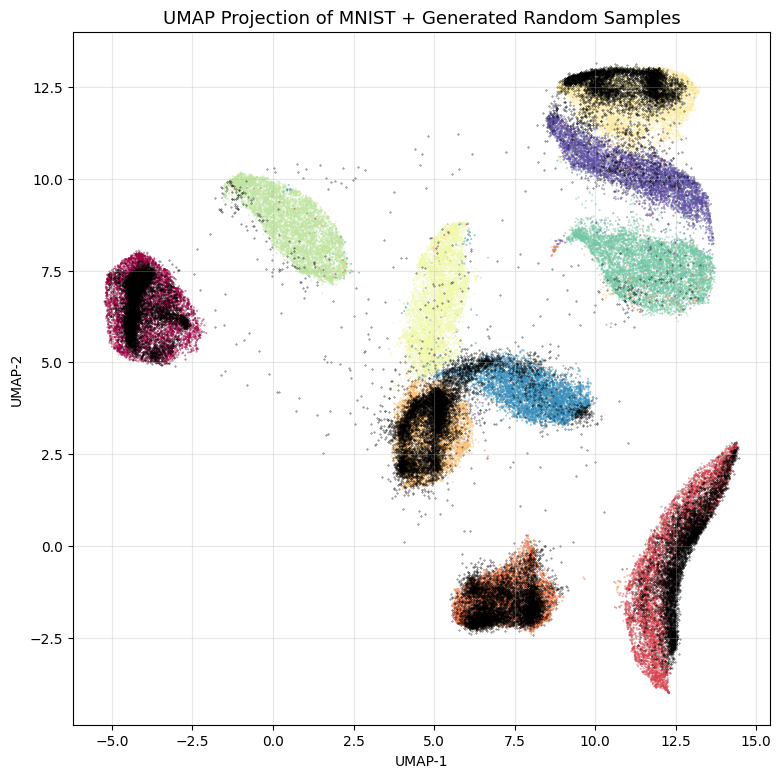

In [26]:
# --- Plot ---
plt.figure(figsize=(9, 9))

# Plot MNIST samples
scatter_mnist = plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=y.cpu(), cmap="Spectral", s=0.1, alpha=0.8, label="MNIST"
)

# Plot generated samples
scatter_gen = plt.scatter(
    embedding_gen[:, 0], embedding_gen[:, 1],
    c="black", s=0.1, alpha=0.8, label="Generated"
)

plt.title("UMAP Projection of MNIST + Generated Random Samples", fontsize=13)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True, alpha=0.3)

# Choose which scatter to colorbar — here, the generated one
cbar.set_label("Predicted Label")

plt.show()


In [38]:
from torch.utils.data import TensorDataset, ConcatDataset, DataLoader
from torchvision import datasets, transforms

sm = torch.nn.Softmax(dim=1)
x_gen =  generated_input.clone().detach().cpu()
#y_hat = sm(rs[-1]) 
y_hat = (sm(model(generated_input)).clone().detach()).cpu().argmax(dim=1)

y_hat = (y_hat < 5)*y_hat + ((y_hat>=5)*(y_hat - 5))
y_hat = F.one_hot(y_hat, num_classes=10).float()
#y_hat = target.float().cpu()

generated_dataset1 = TensorDataset(x_gen, y_hat)


# Combine them
full_dataset = ConcatDataset([generated_dataset1, tasks_dataloaders[1][0].dataset])
#full_dataset = ConcatDataset([generated_dataset1])

# Build dataloader
g = torch.Generator(device="cuda")
g.manual_seed(42)

train_loader2 = DataLoader(
    full_dataset,
    batch_size=100,
    shuffle=True,
    generator=g
)


In [39]:
# Train model
config2 = config.copy()
config2["epochs"] = 20
config2["loss_fn"] = "ce"
config2["save"] = False
config2["setting"] = "offline"
config2 = dotdict(config2)
model2 = BP_network(config=config2)

trainer3 = Trainer(model2, train_loader2, tasks_dataloaders[1][1], config2)
trainer3.train()


Training:
 - layers: [784, 200, 10]
 - num_classes: 10
 - lr: 0.0001
 - lr_fb: 0.0001
 - batch_size: 100
 - batch_size_gen: 35000
 - epochs: 20
 - mode: di
 - num_workers: 0
 - loss_fn: ce
 - optimizer: Adam
 - scheduler: CosineAnnealingLR
 - activation_fun: Tanh
 - device: cuda
 - output_dir: ./outputs
 - seed: 1337
 - taus: [0.02, 0.02, 0.02, 0.016, 0.01]
 - target_lr: 1
 - alpha_di: 0.0017
 - dt_di: 0.02
 - time_constant_ratio: 0.2
 - tmax_di: 2
 - k_p: 2.0
 - eps: 0.0001
 - save: False
 - flatten_imgs: default
 - num_tasks: 2
 - classes_per_task: 5
 - setting: offline
 - in_channels: 1
 - model: BP_network



				Epoch: 001, Train loss: 0.1550 & test loss: 0.5004 & accuracy: 84.61


				Epoch: 002, Train loss: 0.0369 & test loss: 0.5359 & accuracy: 84.43


				Epoch: 003, Train loss: 0.0248 & test loss: 0.5843 & accuracy: 83.50


				Epoch: 004, Train loss: 0.0183 & test loss: 0.5882 & accuracy: 83.88


...

				Epoch: 016, Train loss: 0.0015 & test loss: 0.8985 & accuracy: 80.85


				Epoch: 017, Train loss: 0.0012 & test loss: 0.8718 & accuracy: 82.19


				Epoch: 018, Train loss: 0.0009 & test loss: 0.9639 & accuracy: 80.30


				Epoch: 019, Train loss: 0.0008 & test loss: 1.0198 & accuracy: 80.18


				Epoch: 020, Train loss: 0.0006 & test loss: 0.9576 & accuracy: 81.32


In [ ]:
(train_loss, train_acc), (test_loss, test_acc) = evaluate(model2, tasks_dataloaders[0][0], tasks_dataloaders[0][1], device=model.device)

Train loss: 2.9007 | Train acc: 60.73%
Test  loss: 2.7903 | Test  acc: 61.35%


In [ ]:
config2 = config.copy()
config2["epochs"] = 50
config2["loss_fn"] = "ce"
config2["save"] = False
config2["setting"] = "offline"
config2 = dotdict(config2)
trainer3 = TrainerDFCL(model, train_loader2, tasks_dataloaders[1][1], config)
trainer3.train()

In [ ]:
(train_loss, train_acc), (test_loss, test_acc) = evaluate(model, tasks_dataloaders[0][0], tasks_dataloaders[1][1], device=model.device)

Train loss: 0.8082 | Train acc: 77.57%
Test  loss: 0.4417 | Test  acc: 87.08%


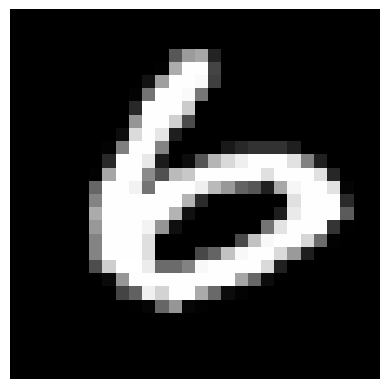

In [26]:
from matplotlib import animation
video = video[:500]

fig = plt.figure()
im = plt.imshow(video[0].cpu().reshape(28,28),cmap="grey")
plt.axis("off")

def update(i):
    im.set_array(video[i].cpu().reshape(28,28))
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(video), interval=50)


In [27]:

ani.save('morphing_animations/contrastive_1.gif', writer='pillow', fps=5)

Animation.save using <class 'matplotlib.animation.PillowWriter'>
